# Newsletter Raw Articles — Exploratory Data Analysis

Dataset: **Supabase Snippet Newsletter Automation Raw Articles.csv**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)

CSV_PATH = 'Supabase Snippet Newsletter Automation Raw Articles.csv'

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')

Loaded 1,154 rows × 9 columns


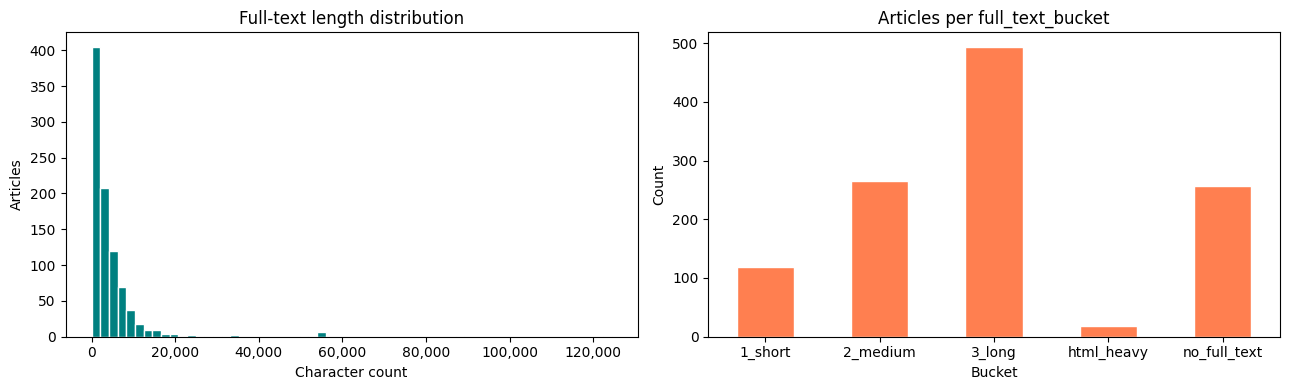

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['full_text_length'].dropna(), bins=60, color='teal', edgecolor='white')
axes[0].set_title('Full-text length distribution')
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Articles')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# By bucket
bucket_order = sorted(df['full_text_bucket'].dropna().unique())
df['full_text_bucket'].value_counts().reindex(bucket_order).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Articles per full_text_bucket')
axes[1].set_xlabel('Bucket')
axes[1].set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
has_title = df['title'].notna() & (df['title'].str.strip().str.lower() != 'null')
print(f"Articles WITH a title : {has_title.sum():,} ({has_title.mean()*100:.1f}%)")
print(f"Articles WITHOUT a title: {(~has_title).sum():,} ({(~has_title).mean()*100:.1f}%)")

Articles WITH a title : 991 (85.9%)
Articles WITHOUT a title: 163 (14.1%)


In [5]:
sample = df[
    (df['full_text_bucket'] == '3_long') &
    (df['title_bucket'] != 'no_title')
][['source_id', 'title', 'full_text_length', 'created_at']].head(10)

sample

,source_id,title,full_text_length,created_at
15,06db5374-72f3-4980-9157-bc260781a783,Australia just experienced its wettest summer in nearly a decade – and the eighth-hottest on record,3556.0,2026-03-03 07:13:56
22,0c8dd182-756b-4c4f-9165-0605129f529c,World Cement Association Annual Conference 2026 to Convene,2044.0,2026-03-02 09:03:13
23,0c8dd182-756b-4c4f-9165-0605129f529c,World Cement Association Annual Conference To Convene In Bangkok,2050.0,2026-03-02 09:03:13
24,0c8dd182-756b-4c4f-9165-0605129f529c,World Cement Association Conference To Convene Industry Leaders,2006.0,2026-03-03 09:03:55
25,0c8dd182-756b-4c4f-9165-0605129f529c,GAIL to invest Rs 1736 crore for wind power project in Maharashtra,2351.0,2026-03-01 15:03:02
26,0c8dd182-756b-4c4f-9165-0605129f529c,SubscriberWrites: India–EU FTA: Free Trade in a World of <b>Carbon</b> Walls - ThePrint,5438.0,2026-03-02 17:04:39
27,0c8dd182-756b-4c4f-9165-0605129f529c,"Stock <b>market</b> holiday on Holi: NSE, BSE to remain closed for <b>trading</b> on THESE days in March",6239.0,2026-03-03 00:02:58
28,0c8dd182-756b-4c4f-9165-0605129f529c,Rain Industries Ltd Opens with Significant Gap Down Amid <b>Market</b> Concerns,5337.0,2026-03-02 17:04:39
29,0c8dd182-756b-4c4f-9165-0605129f529c,BEE Marks 25 Years of Energy Efficiency Leadership - GKToday,3446.0,2026-03-03 09:03:55
30,0c8dd182-756b-4c4f-9165-0605129f529c,"MRF, Ceat, JK Tyre, Apollo Tyres: Tyre stocks fall on spike in crude oil price - Upstox",6239.0,2026-03-02 16:04:10


## Data Cleaning — Title & Full Text

Issues identified in the raw data and addressed below:

**Title**
- Literal string `"null"` → treated as missing
- HTML tags (`<b>`, `<i>`, etc.) → stripped
- HTML entities (`&amp;`, `&#39;`) → unescaped
- Extra whitespace / multiple spaces → normalised

**Full Text**
- Literal string `"null"` → treated as missing
- Raw HTML documents (full `<html>` pages) and inline tags → stripped via BeautifulSoup
- HTML entities → unescaped before parsing
- Handlebars template remnants (`{{#Source}}...`) → removed
- Agency attribution at end (`–IANS`, `(With inputs from agencies.)`) → removed
- Newsletter CTAs (`Sign up: ...`) and bare URLs → removed
- Excessive blank lines / whitespace → normalised
- Truncated articles (ending in `..`) → flagged as `is_truncated`, not dropped

In [21]:
import re
import html as html_lib
from bs4 import BeautifulSoup

# ── Audit: count each issue BEFORE cleaning ──────────────────────────────────
def audit(df):
    r = {}
    # Title
    r['title | literal "null"']      = (df['title'].astype(str).str.strip().str.lower() == 'null').sum()
    r['title | HTML tags']            = df['title'].dropna().str.contains(r'<[^>]+>', regex=True).sum()
    r['title | HTML entities']        = df['title'].dropna().str.contains(r'&[a-z#0-9]+;', regex=True).sum()
    # Full text
    r['full_text | literal "null"']  = (df['full_text'].astype(str).str.strip().str.lower() == 'null').sum()
    r['full_text | raw HTML doc']     = df['full_text'].dropna().str.contains(r'<html', case=False, regex=True).sum()
    r['full_text | any HTML tag']     = df['full_text'].dropna().str.contains(r'<[^>]+>', regex=True).sum()
    r['full_text | Handlebars {{...}}']= df['full_text'].dropna().str.contains(r'\{\{', regex=True).sum()
    r['full_text | truncated (..)']   = df['full_text'].dropna().str.rstrip().str.endswith('..').sum()
    r['full_text | bare URLs']        = df['full_text'].dropna().str.contains(r'https?://', regex=True).sum()
    r['full_text | Sign up CTA']      = df['full_text'].dropna().str.contains(r'Sign up:', regex=False).sum()
    return pd.Series(r).rename('rows_affected').to_frame()

audit(df)

,rows_affected
"title | literal ""null""",0
title | HTML tags,350
title | HTML entities,150
"full_text | literal ""null""",0
full_text | raw HTML doc,20
full_text | any HTML tag,21
full_text | Handlebars {{...}},10
full_text | truncated (..),23
full_text | bare URLs,88
full_text | Sign up CTA,3


In [16]:
# ── Cleaning functions ────────────────────────────────────────────────────────

def clean_title(raw):
    if pd.isna(raw) or str(raw).strip().lower() == 'null':
        return np.nan
    t = html_lib.unescape(str(raw))          # decode &amp; &#39; etc.
    t = re.sub(r'<[^>]+>', '', t)            # strip any HTML tags
    t = re.sub(r'\s+', ' ', t).strip()       # normalise whitespace
    return t if t else np.nan


def clean_full_text(raw):
    if pd.isna(raw) or str(raw).strip().lower() == 'null':
        return np.nan
    t = html_lib.unescape(str(raw))
    # Strip HTML — handles full <html> documents and scattered inline tags
    t = BeautifulSoup(t, 'html.parser').get_text(separator='\n')
    # Handlebars template remnants  {{#Source}}...{{/Disclaimer}}
    t = re.sub(r'\{\{[^}]*\}\}', '', t)
    # Agency attribution at end: "–IANS", "- PTI"
    t = re.sub(r'[\-–]\s*[A-Z]{2,6}\s*$', '', t, flags=re.MULTILINE)
    # "(With inputs from agencies.)" and variants
    t = re.sub(r'\(With inputs from[^)]+\)\.?', '', t)
    # Newsletter sign-up CTAs
    t = re.sub(r'Sign up:.*?(?=\n|$)', '', t)
    # Bare URLs
    t = re.sub(r'https?://\S+', '', t)
    # Normalise whitespace
    t = re.sub(r'[ \t]+', ' ', t)
    t = re.sub(r'\n{3,}', '\n\n', t)
    t = t.strip()
    return t if t else np.nan


df['title_clean']     = df['title'].apply(clean_title)
df['full_text_clean'] = df['full_text'].apply(clean_full_text)
df['is_truncated']    = df['full_text'].astype(str).str.rstrip().str.endswith('..')

print(f"title_clean     — non-null : {df['title_clean'].notna().sum():,} / {len(df):,}")
print(f"full_text_clean — non-null : {df['full_text_clean'].notna().sum():,} / {len(df):,}")
print(f"Truncated articles (flagged): {df['is_truncated'].sum():,}")

title_clean     — non-null : 991 / 1,154
full_text_clean — non-null : 886 / 1,154
Truncated articles (flagged): 23


/var/folders/7s/m5tx7vvs46d2k7slgqhkt2hh0000gp/T/ipykernel_5262/69598173.py:17: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  t = BeautifulSoup(t, 'html.parser').get_text(separator='\n')


In [17]:
# ── Before / After spot-check ─────────────────────────────────────────────────
# Show rows that had at least one known title or full_text issue
dirty_title = df['title'].astype(str).str.contains(r'<[^>]+>|&[a-z#0-9]+;', regex=True, na=False)
dirty_ft    = df['full_text'].astype(str).str.contains(r'\{\{|<html|Sign up:', case=False, regex=True, na=False)

spot = df[dirty_title | dirty_ft][['title', 'title_clean', 'full_text', 'full_text_clean']].head(10)

for i, row in spot.iterrows():
    print(f"── row {i} ─────────────────────────────────────────────")
    print(f"  title_raw  : {str(row['title'])[:200]}")
    print(f"  title_clean: {str(row['title_clean'])[:200]}")
    print(f"  ft_raw     :\n{str(row['full_text'])[:400]}")
    print(f"  ft_clean   :\n{str(row['full_text_clean'])[:400]}")
    print()

── row 9 ─────────────────────────────────────────────
  title_raw  : Fireye Acquires Energy Technology &amp; Control
  title_clean: Fireye Acquires Energy Technology & Control
  ft_raw     :
nan
  ft_clean   :
nan

── row 15 ─────────────────────────────────────────────
  title_raw  : Australia just experienced its wettest summer in nearly a decade – and the eighth-hottest on record
  title_clean: Australia just experienced its wettest summer in nearly a decade – and the eighth-hottest on record
  ft_raw     :
This summer ricocheted from extremely hot to intensely wet across parts of the country, according to the Bureau of Meteorology, with South Australia experiencing some of the season’s most acute swings.
Nationwide, the 2025-26 season was the wettest in nearly a decade, with rainfall 32% higher than average across the country, according to the bureau’s summary, the rainiest since 2016-17.
It was als
  ft_clean   :
This summer ricocheted from extremely hot to intensely wet across p

=== Post-clean issue counts (should all be 0 or near-0) ===
                                rows_affected
title | literal "null"                      0
title | HTML tags                           0
title | HTML entities                       0
full_text | literal "null"                  0
full_text | raw HTML doc                    0
full_text | any HTML tag                    0
full_text | Handlebars {{...}}              1
full_text | truncated (..)                 23
full_text | bare URLs                       3
full_text | Sign up CTA                     0

=== Cleaned column stats ===
       title_clean_len  full_text_clean_len
count            991.0                886.0
mean              75.0               3751.9
std               24.1               5068.4
min                8.0                 37.0
25%               65.0               1018.5
50%               76.0               2409.5
75%               86.0               4820.8
max              326.0              87773.0


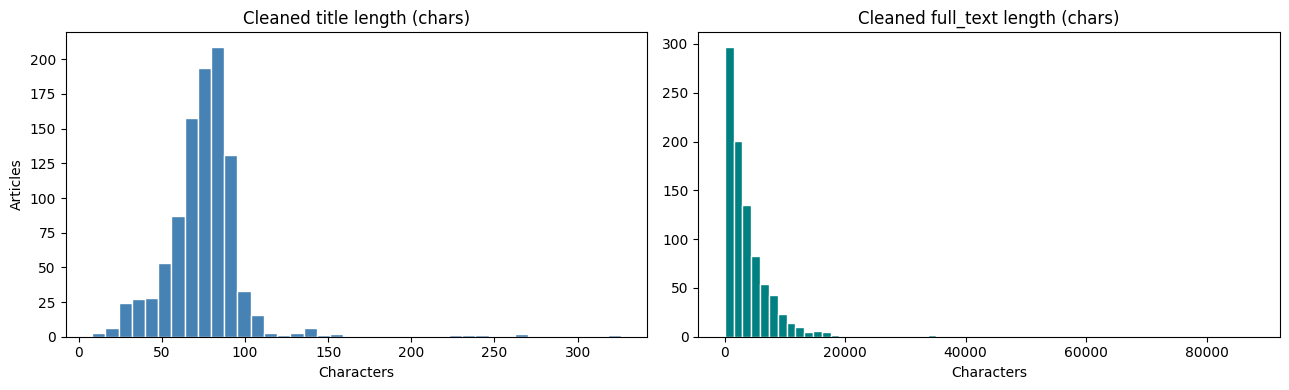

In [27]:
# ── Post-clean audit & length distribution ────────────────────────────────────
print("=== Post-clean issue counts (should all be 0 or near-0) ===")
print(audit(df[["title_clean", "full_text_clean"]].rename(columns={'title_clean': 'title', 'full_text_clean': 'full_text'})))

df['title_clean_len']     = df['title_clean'].str.len()
df['full_text_clean_len'] = df['full_text_clean'].str.len()

print("\n=== Cleaned column stats ===")
print(df[['title_clean_len', 'full_text_clean_len']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['title_clean_len'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Cleaned title length (chars)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Articles')

axes[1].hist(df['full_text_clean_len'].dropna(), bins=60, color='teal', edgecolor='white')
axes[1].set_title('Cleaned full_text length (chars)')
axes[1].set_xlabel('Characters')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 12. Title Similarity — Comparing Three Methods

Working on `title_clean` (991 non-null titles).

| Method | Library | What it measures |
|---|---|---|
| **TF-IDF Cosine** | sklearn | Word-overlap; good for same-topic paraphrases |
| **Fuzzy token-sort ratio** | rapidfuzz | Edit-distance on sorted words; catches near-exact rewording |
| **MinHash LSH** | datasketch | Jaccard on char 3-grams; approximate nearest-neighbour lookup |

In [64]:
titles_s = df['title_clean'].dropna()
titles   = titles_s.tolist()
n        = len(titles)
print(f"{n} titles to compare")

991 titles to compare


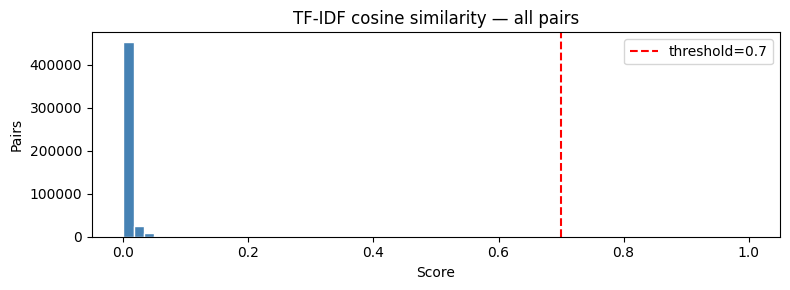

Pairs above 0.7: 42
  1.000  | Plug Power Reports Q4 and Full Year 2025 Results with Strong Sales Growth and Ma
         | Plug Power Reports Q4 and Full Year 2025 Results with Strong Sales Growth and Ma
  1.000  | Cielo Waste Solutions Corp. to Present at the Clean Energy & Renewables Virtual 
         | Cielo Waste Solutions Corp. to Present at the Clean Energy & Renewables Virtual 
  1.000  | Govt to take consensual view before implementing new fuel-emission norms | Auto
         | Govt to take consensual view before implementing new fuel-emission norms | Auto
  1.000  | VCM Report: Carbon credit retirements surge as CORSIA futures fall over 10%
         | VCM Report: Carbon credit retirements surge as CORSIA futures fall over 10%
  1.000  | UNI Photo - UNITED NEWS OF INDIA
         | UNI Photo - UNITED NEWS OF INDIA
  1.000  | Sukhu meets FM, seeks special package to offset deficit after revenue deficit gr
         | Sukhu meets FM, seeks special package to offset deficit after rev

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vec  = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=1)
X    = vec.fit_transform(titles)
cos  = cosine_similarity(X)          # dense n×n
np.fill_diagonal(cos, 0)

COSINE_THRESH = 0.70

fig, ax = plt.subplots(figsize=(8, 3))
upper = cos[np.triu_indices(n, k=1)]
ax.hist(upper, bins=60, color='steelblue', edgecolor='white')
ax.axvline(COSINE_THRESH, color='red', linestyle='--', label=f'threshold={COSINE_THRESH}')
ax.set_title('TF-IDF cosine similarity — all pairs')
ax.set_xlabel('Score'); ax.set_ylabel('Pairs'); ax.legend()
plt.tight_layout(); plt.show()

rows_c, cols_c = np.where((cos >= COSINE_THRESH) & np.triu(np.ones_like(cos, dtype=bool), k=1))
pairs_cos = sorted(zip(cos[rows_c, cols_c], rows_c, cols_c), reverse=True)
print(f"Pairs above {COSINE_THRESH}: {len(pairs_cos)}")
for score, i, j in pairs_cos[:15]:
    print(f"  {score:.3f}  | {titles[i][:80]}")
    print(f"         | {titles[j][:80]}")

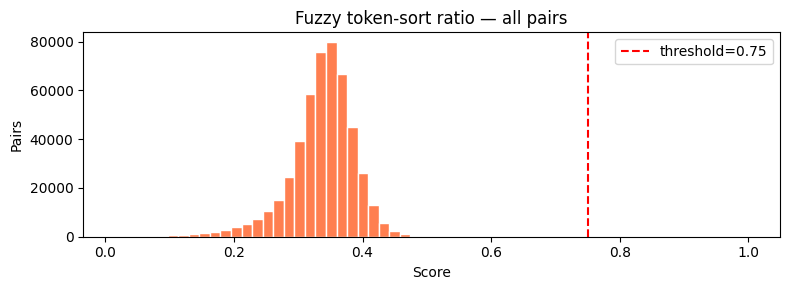

Pairs above 0.75: 49
  1.000  | Plug Power Reports Q4 and Full Year 2025 Results with Strong Sales Growth and Ma
         | Plug Power Reports Q4 and Full Year 2025 Results with Strong Sales Growth and Ma
  1.000  | CIAL to Become India's First Airport to Operate Hydrogen-Powered Buses - Fuel Ce
         | CIAL to Become India's First Airport to Operate Hydrogen-Powered Buses - Fuel Ce
  1.000  | Australian Federal Court Dismisses Santos Greenwashing Case | JD Supra
         | Australian Federal Court Dismisses Santos Greenwashing Case | JD Supra
  1.000  | Cielo Waste Solutions Corp. to Present at the Clean Energy & Renewables Virtual 
         | Cielo Waste Solutions Corp. to Present at the Clean Energy & Renewables Virtual 
  1.000  | Govt to take consensual view before implementing new fuel-emission norms | Auto
         | Govt to take consensual view before implementing new fuel-emission norms | Auto
  1.000  | Western Green Energy Hub ticks phase 1 offtake milestone
         | We

In [66]:
from rapidfuzz import fuzz
from rapidfuzz.process import cdist as rf_cdist

# token_sort_ratio sorts words alphabetically before comparing
# → handles word-order variation like "Conference 2026 to Convene" vs "Conference To Convene In Bangkok"
sim_lev = rf_cdist(titles, titles, scorer=fuzz.token_sort_ratio) / 100.0
np.fill_diagonal(sim_lev, 0)

LEV_THRESH = 0.75

fig, ax = plt.subplots(figsize=(8, 3))
upper_lev = sim_lev[np.triu_indices(n, k=1)]
ax.hist(upper_lev, bins=60, color='coral', edgecolor='white')
ax.axvline(LEV_THRESH, color='red', linestyle='--', label=f'threshold={LEV_THRESH}')
ax.set_title('Fuzzy token-sort ratio — all pairs')
ax.set_xlabel('Score'); ax.set_ylabel('Pairs'); ax.legend()
plt.tight_layout(); plt.show()

rows_l, cols_l = np.where((sim_lev >= LEV_THRESH) & np.triu(np.ones_like(sim_lev, dtype=bool), k=1))
pairs_lev = sorted(zip(sim_lev[rows_l, cols_l], rows_l, cols_l), reverse=True)
print(f"Pairs above {LEV_THRESH}: {len(pairs_lev)}")
for score, i, j in pairs_lev[:15]:
    print(f"  {score:.3f}  | {titles[i][:80]}")
    print(f"         | {titles[j][:80]}")

In [75]:
from datasketch import MinHash, MinHashLSH

LSH_THRESH = 0.50
NUM_PERM   = 128
SHINGLE_K  = 3

def make_minhash(text, k=SHINGLE_K):
    m = MinHash(num_perm=NUM_PERM)
    for i in range(len(text) - k + 1):
        m.update(text[i:i+k].encode('utf-8'))
    return m

minhashes = [make_minhash(t.lower()) for t in titles]

lsh = MinHashLSH(threshold=LSH_THRESH, num_perm=NUM_PERM)
for idx, m in enumerate(minhashes):
    lsh.insert(str(idx), m)

seen, pairs_lsh = set(), []
for i, m in enumerate(minhashes):
    for c in lsh.query(m):
        j = int(c)
        if j == i:
            continue
        key = (min(i, j), max(i, j))
        if key not in seen:
            seen.add(key)
            est = minhashes[key[0]].jaccard(minhashes[key[1]])
            pairs_lsh.append((est, key[0], key[1]))

pairs_lsh.sort(reverse=True)
print(f"Candidate pairs (Jaccard >= {LSH_THRESH}): {len(pairs_lsh)}")
for score, i, j in pairs_lsh[:15]:
    print(f"  {score:.3f}  | {titles[i][:80]}")
    print(f"         | {titles[j][:80]}")

Candidate pairs (Jaccard >= 0.5): 69
  1.000  | Plug Power Reports Q4 and Full Year 2025 Results with Strong Sales Growth and Ma
         | Plug Power Reports Q4 and Full Year 2025 Results with Strong Sales Growth and Ma
  1.000  | CIAL to Become India's First Airport to Operate Hydrogen-Powered Buses - Fuel Ce
         | CIAL to Become India's First Airport to Operate Hydrogen-Powered Buses - Fuel Ce
  1.000  | Australian Federal Court Dismisses Santos Greenwashing Case | JD Supra
         | Australian Federal Court Dismisses Santos Greenwashing Case | JD Supra
  1.000  | Cielo Waste Solutions Corp. to Present at the Clean Energy & Renewables Virtual 
         | Cielo Waste Solutions Corp. to Present at the Clean Energy & Renewables Virtual 
  1.000  | Govt to take consensual view before implementing new fuel-emission norms | Auto
         | Govt to take consensual view before implementing new fuel-emission norms | Auto
  1.000  | Western Green Energy Hub ticks phase 1 offtake milesto

In [89]:
pairs_lsh_non_one = [i for i in pairs_lsh if i[0] != 1]

In [113]:
df.loc[460]

source_id                                                                                                 727bd746-89a9-4f91-82ba-37cfe84b78da
full_text_bucket                                                                                                                        3_long
title_bucket                                                                                                                title_with_symbols
title                                                    Regenerative Business Research Discussed at International Doctoral Consortium and ...
full_text_length                                                                                                                        5174.0
html_percent                                                                                                                               0.0
full_text              -\nTwo-day academic programme examined governance, ethics, and regenerative enterprise models through doctoral conso...

In [110]:
df.title_clean.dropna()[df.title_clean.str.startswith('Regenerative').dropna()]

460    Regenerative Business Research Discussed at International Doctoral Consortium and ...
Name: title_clean, dtype: object

In [ ]:
idx = - 
print(f'score: {pairs_lsh_non_one[idx][0]}')
print(titles[pairs_lsh_non_one[idx][1]], "\n",titles[pairs_lsh_non_one[idx][2]])

score: 0.625
Belgium seizes suspected Russian shadow fleet vessel - POLITICO 
 Belgium Seizes Suspected Russian Shadow Fleet Tanker - Maritime News


In [128]:
pairs_lsh_non_one

[(0.96875, 391, 624),
 (0.90625, 333, 334),
 (0.8984375, 630, 939),
 (0.859375, 388, 622),
 (0.8515625, 339, 440),
 (0.8125, 576, 920),
 (0.796875, 489, 504),
 (0.7578125, 363, 440),
 (0.75, 828, 896),
 (0.75, 16, 17),
 (0.71875, 189, 191),
 (0.703125, 490, 491),
 (0.6796875, 620, 621),
 (0.6796875, 339, 363),
 (0.6484375, 5, 779),
 (0.625, 731, 738),
 (0.625, 17, 18),
 (0.59375, 582, 583),
 (0.5859375, 986, 988),
 (0.5859375, 16, 18),
 (0.578125, 724, 738),
 (0.5625, 832, 834),
 (0.5546875, 829, 830),
 (0.5390625, 19, 61),
 (0.53125, 830, 834),
 (0.5234375, 829, 834),
 (0.5234375, 582, 584),
 (0.484375, 583, 584),
 (0.4765625, 829, 832),
 (0.4765625, 489, 652),
 (0.4453125, 830, 832),
 (0.4296875, 504, 652),
 (0.40625, 716, 718),
 (0.359375, 322, 362),
 (0.28125, 65, 73),
 (0.265625, 370, 600),
 (0.2578125, 23, 503),
 (0.203125, 97, 941),
 (0.171875, 772, 821),
 (0.1171875, 177, 483)]

In [68]:
set_cos = {(i, j) for _, i, j in pairs_cos}
set_lev = {(i, j) for _, i, j in pairs_lev}
set_lsh = {(i, j) for _, i, j in pairs_lsh}

print("Pairs flagged by each method:")
print(f"  TF-IDF cosine  >= {COSINE_THRESH} : {len(set_cos):4d}")
print(f"  Fuzzy Lev      >= {LEV_THRESH}  : {len(set_lev):4d}")
print(f"  MinHash LSH    >= {LSH_THRESH}  : {len(set_lsh):4d}")
print(f"  All three agree         : {len(set_cos & set_lev & set_lsh):4d}")
print(f"  Cosine ∩ Lev            : {len(set_cos & set_lev):4d}")
print(f"  Cosine ∩ LSH            : {len(set_cos & set_lsh):4d}")
print(f"  Lev ∩ LSH               : {len(set_lev & set_lsh):4d}")

# Greedy dedup: mark the second article in each pair as the duplicate
dup_cos = {j for _, i, j in pairs_cos}
dup_lev = {j for _, i, j in pairs_lev}
dup_lsh = {j for _, i, j in pairs_lsh}

print(f"\nArticles flagged as duplicates (greedy — keep first, drop second):")
print(f"  TF-IDF cosine : {len(dup_cos):4d} / {n} ({len(dup_cos)/n*100:.1f}%)")
print(f"  Fuzzy Lev     : {len(dup_lev):4d} / {n} ({len(dup_lev)/n*100:.1f}%)")
print(f"  MinHash LSH   : {len(dup_lsh):4d} / {n} ({len(dup_lsh)/n*100:.1f}%)")

Pairs flagged by each method:
  TF-IDF cosine  >= 0.7 :   42
  Fuzzy Lev      >= 0.75  :   49
  MinHash LSH    >= 0.5  :   69
  All three agree         :   40
  Cosine ∩ Lev            :   40
  Cosine ∩ LSH            :   42
  Lev ∩ LSH               :   46

Articles flagged as duplicates (greedy — keep first, drop second):
  TF-IDF cosine :   40 / 991 (4.0%)
  Fuzzy Lev     :   46 / 991 (4.6%)
  MinHash LSH   :   60 / 991 (6.1%)


## Rough

In [ ]:
idx = 0
print(df[df["html_percent"] > 0]["full_text"].iloc[19])

<html>
<head>
<META NAME="robots" CONTENT="noindex,nofollow">
<script src="/_Incapsula_Resource?SWJIYLWA=5074a744e2e3d891814e9a2dace20bd4,719d34d31c8e3a6e6fffd425f7e032f3">
</script>
<body>
</body></html>



In [54]:
print(df[df["html_percent"] > 0]["full_text_clean"].iloc[11])

PressReader.com - Digital Newspaper & Magazine Subscriptions


To check with Trafi/otherwise how to rectify:

* html: 0: Financial Services Commission Expands...(html content not rendering but comes in towards the end)
* html: 11, 10: PressReader.com (html content doesn't load. Paywalled + js likely) (this way, all of pressreader.com will result in the exact same content; will have to filter/select items with len > something)
* 460: why is this a truncated title? Regenerative Business Research Discussed at International Doctoral Consortium and ...

Notes
* Incapsula turns Nan

In [ ]:
df[df["html_percent"] > 0].iloc[10]

source_id                                                                                                 52b538f9-655c-42c3-ae56-0427755bb73f
full_text_bucket                                                                                                                    html_heavy
title_bucket                                                                                                                title_with_symbols
title                                          India-eu trade deal text falls short on recognising local <b>CBAM</b> accreditors - PressReader
full_text_length                                                                                                                       55724.0
html_percent                                                                                                                              73.0
full_text              \r\n<!DOCTYPE html>\r\n<html class="no-js" lang="en">\r\n<head>\r\n    <title>PressReader.com - Digital Newspaper & ...

## 13. LSH Accuracy — Evaluation on Labeled Ground-Truth Dataset

Using **`Tasks - Duplicates & Non-Duplicates.csv`** — 114 manually labeled articles.

| Column | Meaning |
|---|---|
| `new_id` | Shared value = duplicate group; `NaN` = no known duplicate |
| `id` | Row identifier — **ignored** |

For each threshold **t**, a pair (i, j) is a **predicted duplicate** if MinHash Jaccard ≥ t.  
- **TP**: pair predicted *and* shares same `new_id`  
- **FP**: pair predicted *but* different / null `new_id`  
- **FN**: same `new_id` but pair *not* predicted  
- Precision = TP / (TP+FP) &nbsp;&nbsp; Recall = TP / (TP+FN) &nbsp;&nbsp; F1 = harmonic mean


In [129]:
import itertools

# ── Load labeled dataset ──────────────────────────────────────────────────────
df_gt = pd.read_csv('Tasks - Duplicates & Non-Duplicates.csv')
df_gt['title_clean'] = df_gt['title'].apply(clean_title)
# Fallback to raw title if cleaning returns NaN
df_gt['title_for_lsh'] = df_gt['title_clean'].fillna(df_gt['title'].astype(str))
titles_gt = df_gt['title_for_lsh'].tolist()
n_gt      = len(titles_gt)

# ── Ground-truth duplicate pairs from new_id ─────────────────────────────────
gt_pairs = set()
for gid, grp in df_gt[df_gt['new_id'].notna()].groupby('new_id'):
    for a, b in itertools.combinations(sorted(grp.index.tolist()), 2):
        gt_pairs.add((a, b))

total_pairs = n_gt * (n_gt - 1) // 2
print(f"Articles        : {n_gt}")
print(f"Total pairs     : {total_pairs:,}")
print(f"Dup groups      : {df_gt['new_id'].nunique()}  "
      f"({df_gt['new_id'].notna().sum()} articles)")
print(f"GT dup pairs    : {len(gt_pairs)}")
print(f"Non-dup articles: {df_gt['new_id'].isna().sum()}")


Articles        : 114
Total pairs     : 6,441
Dup groups      : 12  (27 articles)
GT dup pairs    : 18
Non-dup articles: 87


In [130]:
# ── Compute MinHash for all labeled articles ──────────────────────────────────
# Reuses make_minhash(), NUM_PERM, SHINGLE_K from §12
mh_gt = [make_minhash(t.lower()) for t in titles_gt]

# All-pairs Jaccard estimate  (114 × 113 / 2 = 6,441 pairs) — exact MinHash estimate
jac_gt = np.zeros((n_gt, n_gt))
for i in range(n_gt):
    for j in range(i + 1, n_gt):
        s = mh_gt[i].jaccard(mh_gt[j])
        jac_gt[i, j] = s
        jac_gt[j, i] = s

gt_scores = np.array([jac_gt[a, b] for a, b in sorted(gt_pairs)])
print(f"Jaccard scores for the {len(gt_pairs)} GT duplicate pairs:")
for (a, b), sc in zip(sorted(gt_pairs), gt_scores):
    print(f"  {sc:.4f}  | {titles_gt[a][:70]}")
    print(f"         | {titles_gt[b][:70]}")


Jaccard scores for the 18 GT duplicate pairs:
  0.3828  | India and EU Conclude Free Trade Agreement Linking Climate Action and 
         | India and EU Conclude Free Trade Agreement With CBAM Flexibilities and
  0.6094  | Vingroup Launches Carbon Credit Projects for Electric Motorcycles and 
         | Vingroup Launches Carbon Credit Projects for Electric Vehicles and Cha
  0.1484  | India Releases Decarbonization Roadmaps For Cement And Aluminium Secto
         | India Establishes Carbon Credit Trading Scheme Framework For Emissions
  0.3047  | LanzaTech Awarded Contract To Build Ethanol Facility In India Using Ag
         | LanzaTech Wins Contract to Build Bio-Ethanol Plant in Uttar Pradesh
  0.4219  | SAF One Energy Forms Strategic Partnership To Scale Sustainable Aviati
         | Honeywell, Tata Projects, SAF+ One Partner To Scale Sustainable Aviati
  0.5547  | India Expands Carbon Credit Trading Scheme to Cover 490 Industrial Ent
         | India Expands Carbon Credit Trading Sc

In [131]:
# ── Threshold sweep: precision / recall / F1 ─────────────────────────────────
thresholds = np.round(np.arange(0.10, 1.01, 0.05), 2)
eval_rows  = []

for thresh in thresholds:
    r, c  = np.where(np.triu(jac_gt >= thresh, k=1))
    pred  = set(zip(r.tolist(), c.tolist()))
    tp    = len(pred & gt_pairs)
    fp    = len(pred - gt_pairs)
    fn    = len(gt_pairs - pred)
    prec  = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1    = 2*prec*rec / (prec+rec) if (prec + rec) > 0 else 0.0
    eval_rows.append({
        'threshold' : thresh,
        'predicted' : len(pred),
        'TP': tp, 'FP': fp, 'FN': fn,
        'precision' : round(prec, 3),
        'recall'    : round(rec,  3),
        'f1'        : round(f1,   3),
    })

eval_df = pd.DataFrame(eval_rows)
print(eval_df[['threshold','predicted','TP','FP','FN','precision','recall','f1']].to_string(index=False))


 threshold  predicted  TP  FP  FN  precision  recall    f1
      0.10        992  16 976   2      0.016   0.889 0.032
      0.15        342  15 327   3      0.044   0.833 0.083
      0.20        165  15 150   3      0.091   0.833 0.164
      0.25         74  13  61   5      0.176   0.722 0.283
      0.30         37  11  26   7      0.297   0.611 0.400
      0.35         21   8  13  10      0.381   0.444 0.410
      0.40         13   7   6  11      0.538   0.389 0.452
      0.45         10   5   5  13      0.500   0.278 0.357
      0.50          8   5   3  13      0.625   0.278 0.385
      0.55          8   5   3  13      0.625   0.278 0.385
      0.60          5   3   2  15      0.600   0.167 0.261
      0.65          3   2   1  16      0.667   0.111 0.190
      0.70          1   0   1  18      0.000   0.000 0.000
      0.75          1   0   1  18      0.000   0.000 0.000
      0.80          1   0   1  18      0.000   0.000 0.000
      0.85          1   0   1  18      0.000   0.000 0.0

In [135]:
# ── Inspect results at a chosen threshold ────────────────────────────────────
INSPECT_THRESH = 0.5   # <-- change this

r, c  = np.where(np.triu(jac_gt >= INSPECT_THRESH, k=1))
pred  = set(zip(r.tolist(), c.tolist()))

tp_pairs = sorted(pred & gt_pairs, key=lambda p: -jac_gt[p])
fp_pairs = sorted(pred - gt_pairs, key=lambda p: -jac_gt[p])
fn_pairs = sorted(gt_pairs - pred,  key=lambda p: -jac_gt[p])
tn_count = total_pairs - len(tp_pairs) - len(fp_pairs) - len(fn_pairs)

def pairs_to_df(pairs):
    rows = []
    for a, b in pairs:
        rows.append({
            'score'   : round(float(jac_gt[a, b]), 4),
            'new_id_A': df_gt.loc[a, 'new_id'],
            'new_id_B': df_gt.loc[b, 'new_id'],
            'title_A' : titles_gt[a],
            'title_B' : titles_gt[b],
        })
    cols = ['score', 'new_id_A', 'new_id_B', 'title_A', 'title_B']
    return pd.DataFrame(rows, columns=cols) if rows else pd.DataFrame(columns=cols)

print(f"Threshold = {INSPECT_THRESH}")
print(f"  TP={len(tp_pairs)}  FP={len(fp_pairs)}  FN={len(fn_pairs)}  TN={tn_count:,}\n")

print("── True Positives (correctly flagged as duplicates) ─────────────────")
display(pairs_to_df(tp_pairs))

print("\n── False Positives (flagged as duplicates but are NOT) ──────────────")
display(pairs_to_df(fp_pairs))

print("\n── False Negatives (real duplicates that were missed) ───────────────")
display(pairs_to_df(fn_pairs))

print(f"\n── True Negatives ───────────────────────────────────────────────────")
print(f"  {tn_count:,} pairs correctly not flagged")


Threshold = 0.5
  TP=5  FP=3  FN=13  TN=6,420

── True Positives (correctly flagged as duplicates) ─────────────────


,score,new_id_A,new_id_B,title_A,title_B
0,0.6719,7.0,7.0,CF Industries and POET Launch Low-Carbon Fertilizer and Ethanol Supply Chain Pilot,CF Industries and POET Partner to Pilot Low-Carbon Fertilizer Supply Chain
1,0.6641,9.0,9.0,Air Products Awarded Over $140 Million NASA Liquid Hydrogen Supply Contract,Air Products Secures Over $140 Million Liquid Hydrogen Supply Contract with NASA
2,0.6094,2.0,2.0,Vingroup Launches Carbon Credit Projects for Electric Motorcycles and Charging Stations,Vingroup Launches Carbon Credit Projects for Electric Vehicles and Charging Infrastructure
3,0.5781,12.0,12.0,Singapore's Keppel and Aster to Jointly Develop Sustainable Aviation Fuel Production Facility,Keppel and Aster Partner on Singapore Sustainable Aviation Fuel Facility Development
4,0.5547,6.0,6.0,India Expands Carbon Credit Trading Scheme to Cover 490 Industrial Entities,India Expands Carbon Credit Trading Scheme With New Industrial Emission Targets



── False Positives (flagged as duplicates but are NOT) ──────────────


,score,new_id_A,new_id_B,title_A,title_B
0,1.0000,4.0,NaN,LanzaTech Wins Contract to Build Bio-Ethanol Plant in Uttar Pradesh,LanzaTech Wins Contract to Build Bio-Ethanol Plant in Uttar Pradesh
1,0.6328,NaN,NaN,Bio-Based Sustainable Aviation Fuel Market Projected to Reach $4.77 Billion by 2032,Global Sustainable Aviation Fuel Market Projected to Reach USD 39.28 Billion by 2035
2,0.5625,NaN,NaN,Joint Venture Launches Digital Infrastructure Supporting Article 6 Paris Agreement Carbon Markets,UN Launches Digital Infrastructure to Operationalize Article 6 Paris Agreement



── False Negatives (real duplicates that were missed) ───────────────


,score,new_id_A,new_id_B,title_A,title_B
0,0.4297,9.0,9.0,Air Products Awarded Over $140 Million NASA Liquid Hydrogen Supply Contract,Air Products Awarded NASA Contracts Totaling Over 140 Million Dollars
1,0.4219,5.0,5.0,SAF One Energy Forms Strategic Partnership To Scale Sustainable Aviation Fuel Production,"Honeywell, Tata Projects, SAF+ One Partner To Scale Sustainable Aviation Fuel Production"
2,0.3828,1.0,1.0,India and EU Conclude Free Trade Agreement Linking Climate Action and Commerce,India and EU Conclude Free Trade Agreement With CBAM Flexibilities and Clean Tech Cooperation
3,0.3359,10.0,10.0,Sankla Buildcoon Signs MoU To Develop Rs 15000 Crore Sustainable Aviation Fuel Plant,Sankla Buildcoon Announces Fifteen Thousand Crore Rupee Sustainable Aviation Fuel Investment
4,0.3359,10.0,10.0,"Sankla Renewables Signs Agreement For Rs15,000 Crore Sustainable Aviation Fuel Project",Sankla Buildcoon Signs MoU To Develop Rs 15000 Crore Sustainable Aviation Fuel Plant
5,0.3047,4.0,4.0,LanzaTech Awarded Contract To Build Ethanol Facility In India Using Agricultural Waste,LanzaTech Wins Contract to Build Bio-Ethanol Plant in Uttar Pradesh
6,0.2891,9.0,9.0,Air Products Awarded NASA Contracts Totaling Over 140 Million Dollars,Air Products Secures Over $140 Million Liquid Hydrogen Supply Contract with NASA
7,0.2500,10.0,10.0,"Sankla Renewables Signs Agreement For Rs15,000 Crore Sustainable Aviation Fuel Project",Sankla Buildcoon Announces Fifteen Thousand Crore Rupee Sustainable Aviation Fuel Investment
8,0.2266,11.0,11.0,US Government Initiates Formal Process For Possible California Offshore Oil Leasing,Trump Administration Invites Oil Industry Nominations for California Offshore Drilling Leases
9,0.2109,8.0,8.0,Republican Lawmakers Plan Task Force for Year-Round E15 Ethanol Fuel Sales,Trump Calls Congress to Finalize Year-Round E15 Fuel Agreement for Farmers



── True Negatives ───────────────────────────────────────────────────
  6,420 pairs correctly not flagged
